## Mini-Project
The mini-project consists of an end-to-end pipeline for supervised learning, where the week's knowledge is all put into use through the following 4 stages:
- EDA: Analyzing the structure and dependencies between variables.
- Preprocessing: Managing missing values, encoding categoricals using one-hot method, and scaling numeric features (fitting on training set only to avoid data leakage).
- Train/Test Split: Using unseen data for testing purposes.
- Modeling & Evaluation: Training and evaluating several models by chosen metrics of classification or regression and comparing them to the baseline model.

## Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay



## Load the Dataset

In [4]:
df=pd.read_csv("Heart_Disease_Prediction.csv")
df.head(10)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [8]:
df.shape

(270, 14)

## Check Missing Values

In [9]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

No missing values were found in the dataset.

## Check Diplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
The dataset contains no duplicate records.

## Choosing Target Variable Distribution 

In [12]:
df["Heart Disease"].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

To know the number of individuals who have heart disease and those who don't .
The distribution of the target variable is shown below:
- Absence
- Persence
Thus, the nature of the problem Nature is **Binary Classification**
Classification or Regression: The problem is a classification task, not regression, because the target variable (Heart Disease) represents distinct categories rather than continuous numerical values.
Binary Nature: Since the target variable has only two possible outcomes—Absence (150 cases) and Presence (120 cases) the nature of the problem is specifically binary classification.

## Class Distribution Visualization

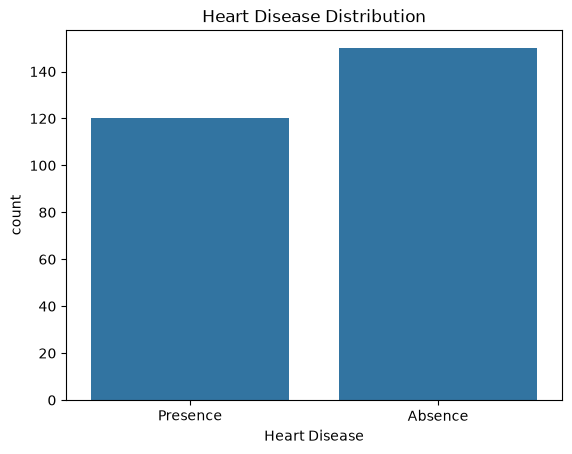

In [14]:
sns.countplot(data=df,x="Heart Disease")
plt.title("Heart Disease Distribution")
plt.show()

The plot shows that the categories looks like fairly balanced.

## Exploratory Data Analysis (EDA)
Now we will see the connection between variables by visualization methods.

## Numerical Features Distribution

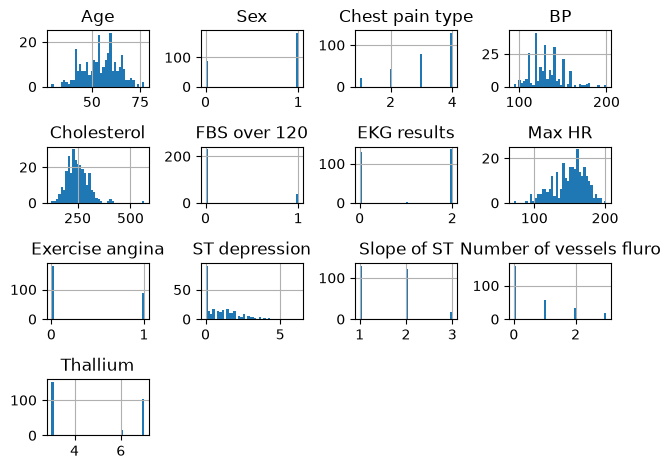

In [19]:
n_c=df.select_dtypes(include=["int64","float64"]).columns
df[n_c].hist(bins=40)
plt.title("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

The histogram provides insights into the distribution of each numeric atrribute as well as form of skewness and outliers that may exist.

## Correlation Heatmap

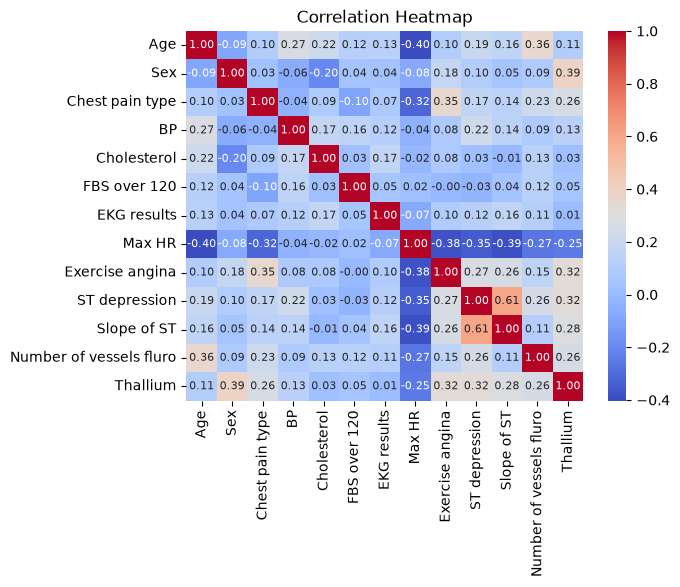

In [27]:
sns.heatmap(df[n_c].corr(),annot=True,cmap="coolwarm",fmt=".2f",annot_kws={"size": 8})
plt.title("Correlation Heatmap")
plt.show()

## Important Information Obtained from Correlation Heatmap Plot:
- Maximum Positive Correlation: The strongest positive correlation exists between ST depression and Slope of ST with a value of (0.61).
- Moderate Positive Correlations: 
  - Age has a moderate positive correlation with Max HR inverse relationship, BP (0.27), and Cholesterol (0.22).
  - Thallium has a moderate correlation with Sex (0.39), and Exercise angina (0.32).
- Maximum Negative Correlation: Max HR has a relatively high negative correlation with Age (-0.40), Exercise angina (-0.38), Slope of ST (-0.39), and Chest pain type (-0.32).
- Multicollinearity: In general, all features have a weak-to-moderate correlation with one another. Therefore, there is a lack of multicollinearity among them.


## Boxplots for Outlier Detection

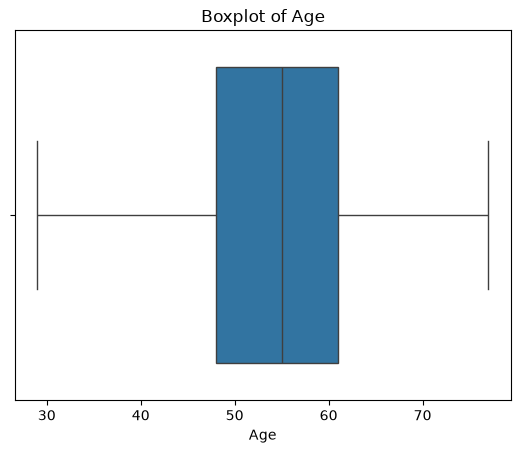

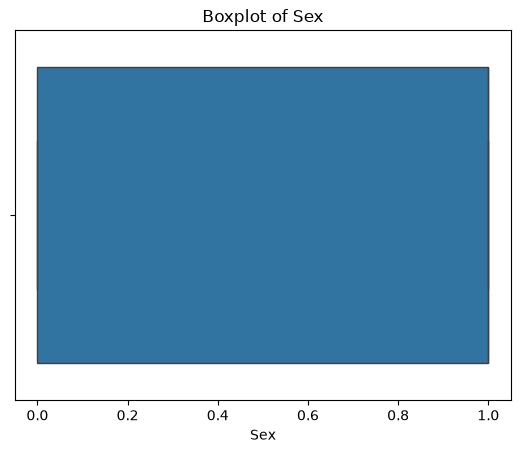

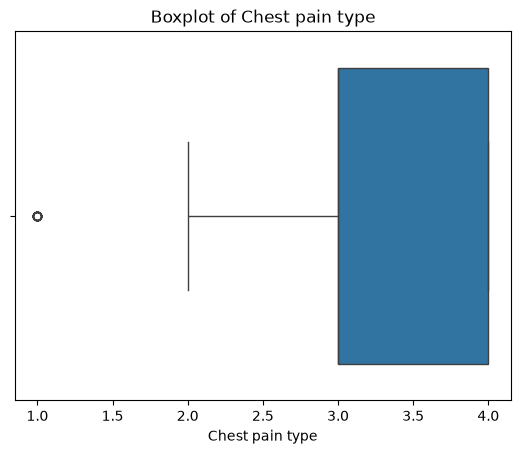

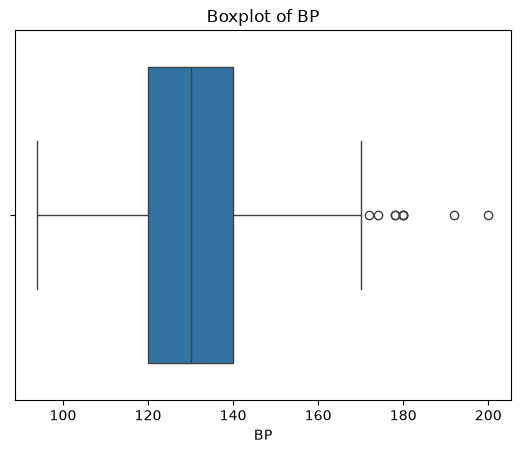

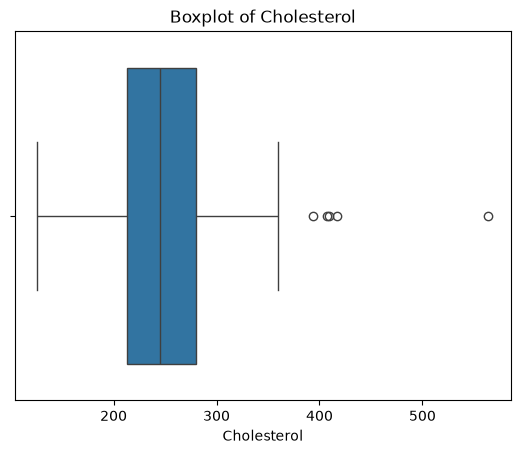

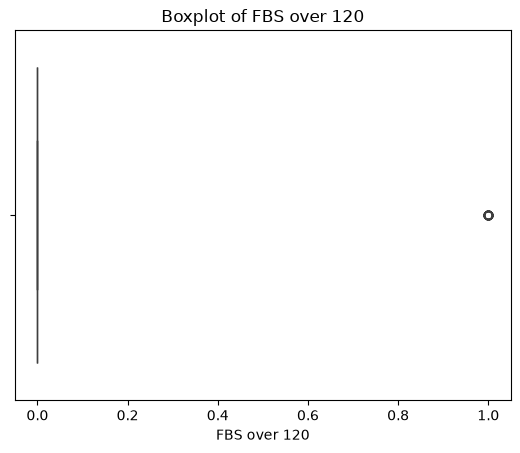

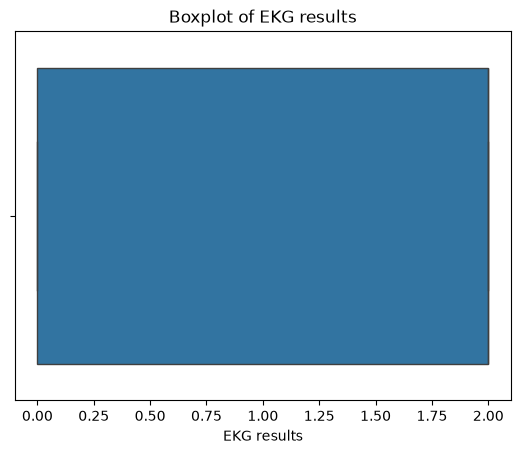

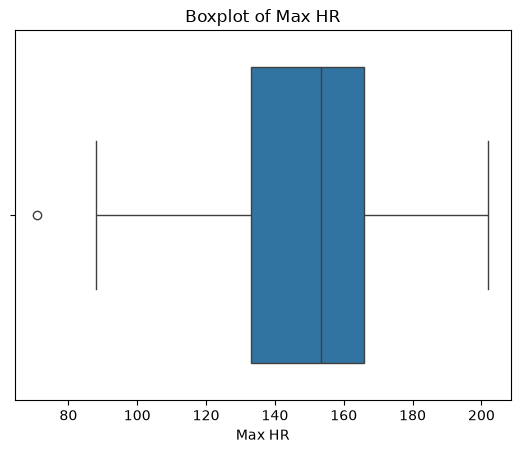

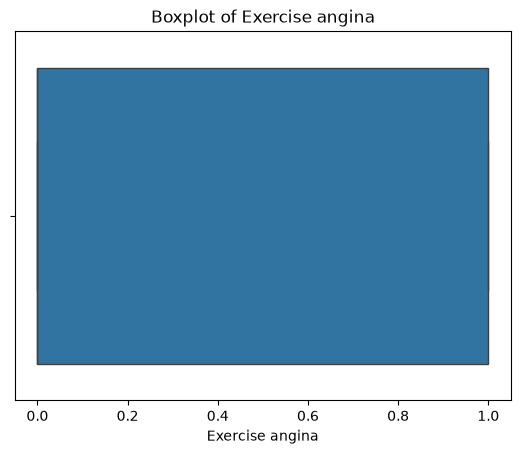

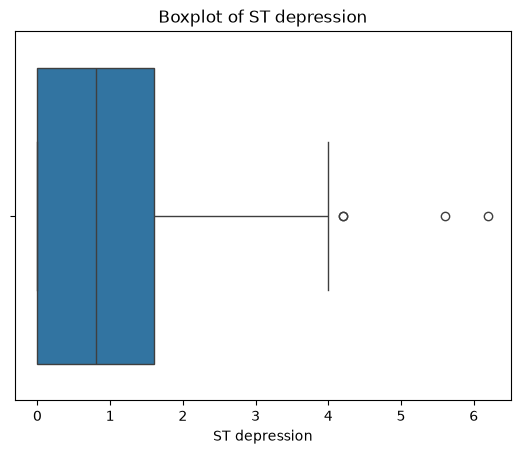

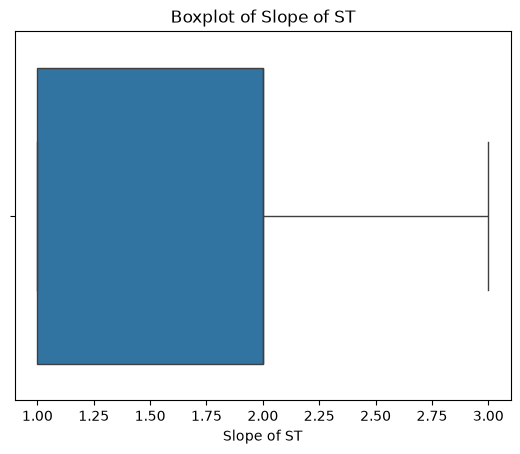

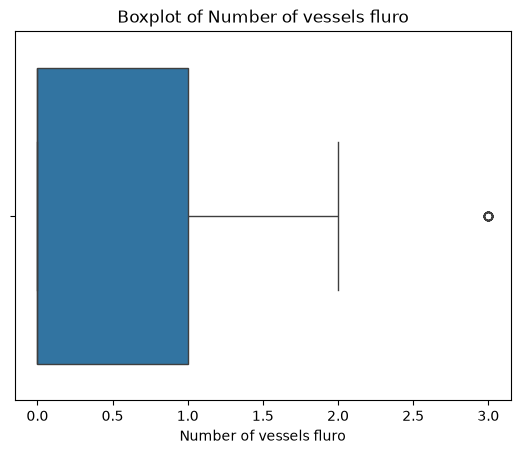

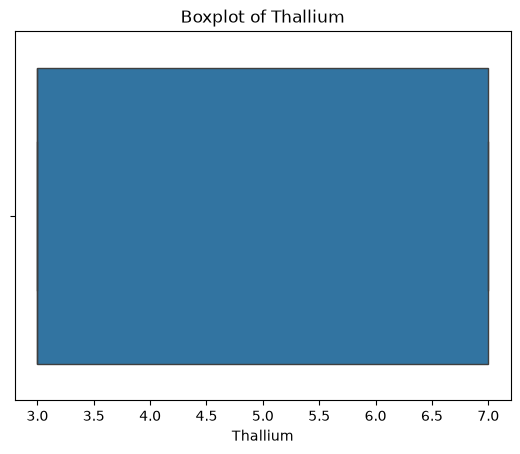

In [28]:
for col in n_c:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

- Boxplot of Age
The distribution of age is fairly symmetric with no outliers, centered around 50–60 years.
- Boxplot of Sex

Categorical binary variable represented as 0 and 1; boxplot is not meaningful here since values are strictly binary.
- Boxplot of Chest pain type

Contains values ranging from 1 to 4 with a single potential outlier on the lower bound (around 1.0).

- Boxplot of BP (Blood Pressure)
Shows several high-value outliers above ~170, indicating right-skewness in blood pressure distribution.

- Boxplot of Cholesterol
Displays a few upper-bound outliers extending past 400, up to ~560, suggesting high cholesterol anomalies in the dataset.

- Boxplot of FBS over 120
Binary feature (0 or 1); shows a sparse distribution with an isolated point at 1.0.

- Boxplot of EKG results
Categorical discrete feature with values mostly spanning between 0 and 2.

- Boxplot of Max HR (Maximum Heart Rate)
Shows a single lower-bound outlier around ~71, while the rest of the heart rates are evenly distributed between ~90 and ~202.

- Boxplot of Exercise angina
Binary indicator (0 or 1) showing presence or absence of exercise-induced angina.

- Boxplot of ST depression
Displays noticeable right-skewness with multiple high-value outliers extending from 4 up to around 6.2.

- Boxplot of Slope of ST
Represents a categorical or discrete feature with values spanning primarily between 1.0 and 3.0, showing no extreme outliers.

- Boxplot of Number of vessels fluro
Discrete variable ranging mostly from 0 to 2, with a single upper-bound outlier located at value 3.0.

- Boxplot of Thallium
Represents Thallium stress test results with values distributed across discrete categories between 3.0 and 7.0, with no visible outliers.

Some continuous variables such as BP, Cholesterol, and ST depression show some outliers on the upper side, which might have to be dealt with or capped depending on how sensitive the selected machine learning model is.

## Pair plot


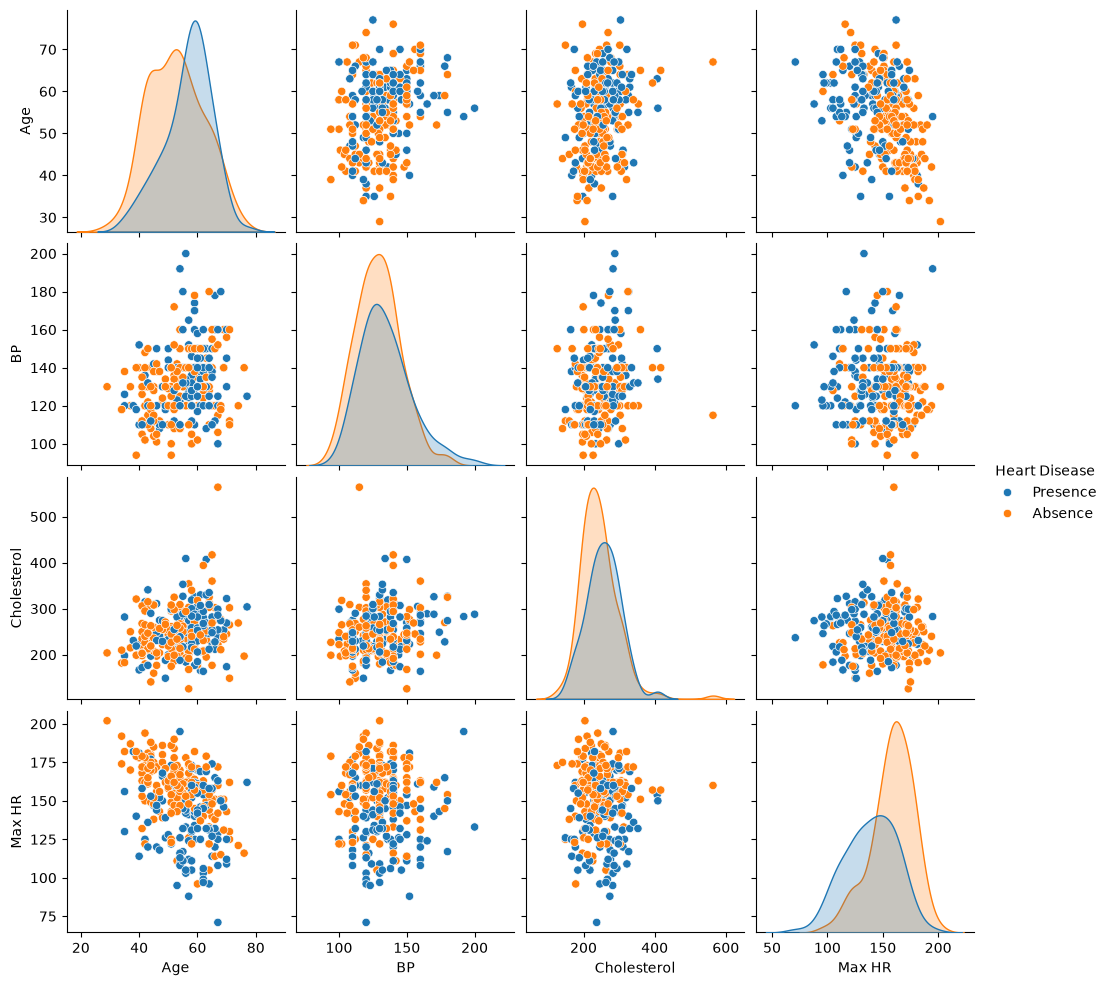

In [ ]:
selected = ["Age", "BP", "Cholesterol", "Max HR", "Heart Disease"]
sns.pairplot(df[selected], hue="Heart Disease")
plt.show()

The Pairplot provides a visual overview of the relationship between important features and the target variable.

## Correlation with Target

In [ ]:
df_corr=df.copy() ##because the type of the target column is str not numeric so we should change it temporarily
df_corr["Heart Disease"]=df_corr["Heart Disease"].map({"Presence":1,"Absence":0})
corr_target=df_corr.corr(numeric_only=True)["Heart Disease"].sort_values(ascending=False)
corr_target

Heart Disease              1.000000
Thallium                   0.525020
Number of vessels fluro    0.455336
Exercise angina            0.419303
ST depression              0.417967
Chest pain type            0.417436
Slope of ST                0.337616
Sex                        0.297721
Age                        0.212322
EKG results                0.182091
BP                         0.155383
Cholesterol                0.118021
FBS over 120              -0.016319
Max HR                    -0.418514
Name: Heart Disease, dtype: float64

correlation values will help in determining which attributes are mostly correlated with heart disease prediction,this attributs are supposed to have a greater contribution in machine learning models.

## EDA summary
From the previous analysis we determined that:
- there are no missing values in the dataset.
- thera are no duplicate values in the dataset.
- the target attribute is binary (Presence/Absence).
- some numerical attrbuits have moderate correlation with the target attribute.
- some outliers are present but reasonable for medical data. 

## Data Preprocessing
Befor the training process the data needs to be preprocessed by doing the following steps:
- Target variable encoding
- categorical variable encoding
- spliting of the data into training and test datasets
- numerical variable scalling
This ensures that model accuracy is improved without any data leakage.

## Seprate Features and Target


In [33]:
x=df.drop("Heart Disease",axis=1)
y=df["Heart Disease"]

The feature x contain all patient information while the target y contains the heart disease diagnosis.

## Encoding the target variable
In machine learning models require numerical targets ,so the target variable should converted into numbers.

In [37]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(encoder.classes_)

['Absence' 'Presence']


This means that Absence become zero and Presence become 1

## Check for categoral feature

In [39]:
x.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

All inputs are variable are numeric,hence One-Hot-Enoding is not necessary for this dataset
so The target variable encoding was the only required step. 

## Train-Test Split
The dataset is devided into training and testing sets.

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Now lets verify the sizes of the training and testing sets.

In [43]:
print("Training set:",x_train.shape)
print("Testing set",y_train.shape)

Training set: (216, 13)
Testing set (216,)


The dataset has been successfully split into training and testing data.

## Feature Scaling
Most machine learning models are more effective when the numeric features are scaled.
In order to prevent data leakage, the scaler is trained on the training set and then used on the testing set.

In [65]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
y_train_scaled=scaler.transform(x_test)
x_test_scaled = scaler.transform(x_test)

- The fit_transform() function is used on the training dataset only.
- The transform() function is used on the testing dataset.

## Verify the Scaled data

In [49]:
x_train_scaled[:5]

array([[-0.63296991, -1.52416434, -1.21490572,  0.12509482,  0.40639114,
        -0.39380225, -1.04259375,  0.56612833, -0.7367884 , -0.9343038 ,
         0.66200384, -0.71458405, -0.90541914],
       [ 0.46519475,  0.65609723,  0.8432875 ,  2.14322204,  1.47854898,
        -0.39380225,  0.96812277, -0.39777057,  1.35724179,  1.95963424,
         2.30559959, -0.71458405,  1.15321806],
       [-0.19370404,  0.65609723, -0.18580911, -0.09914154, -0.08095333,
         2.53934556,  0.96812277,  1.04807779, -0.7367884 , -0.9343038 ,
        -0.98159191,  2.4141353 , -0.90541914],
       [-0.52315344,  0.65609723, -0.18580911,  0.46144936, -0.33437246,
        -0.39380225, -1.04259375,  0.60994192, -0.7367884 , -0.42360885,
         0.66200384,  0.3283224 ,  1.15321806],
       [-0.08388758, -1.52416434, -0.18580911, -1.22032333, -0.70475426,
        -0.39380225, -1.04259375,  0.39087399, -0.7367884 ,  0.4275494 ,
         0.66200384, -0.71458405, -0.90541914]])

In this way, data leakage can be avoided. The features are now standardized and ready for training the machine learning model.

## Baseline
## Befor actually training our machine learning models we define a simple baseline model.
this model will always predict the class that occurs the most often the aim is to beat the baseline model this model can be used for comparison ,a good machine learning model will definitely do better than baseline model.

In [54]:
baseline=DummyClassifier(strategy="most_frequent")
baseline.fit(x_train_scaled,y_train)
baseline_pred=baseline.predict(x_test)
baseline_accuracy=accuracy_score(y_test,baseline_pred)
print("Baseline accuracy is:",baseline_accuracy)

Baseline accuracy is: 0.6111111111111112


The baseline model serves as a reference point to the other model, a useful machine learning model should perform better than it.

## Model 1 Logistic Regression
Logistic Regression is a model used for performing binary classification.
Logistic Regression gives the probability of a sample being of a certain class.

In [ ]:
logistic = LogisticRegression(random_state=42)
logistic.fit(x_train_scaled, y_train)
logistic_predict = logistic.predict(x_test_scaled)
logistic_accuracy = accuracy_score(y_test, logistic_predict)
print("Logistic Regression accuracy is:", logistic_accuracy)

Logistic Regression accuracy is: 0.9074074074074074


## Logistic Regression Evaluation


In [68]:
logistic_accuracy=accuracy_score(y_test,logistic_predict)
logistic_percision=precision_score(y_test,logistic_predict)
logistic_recall=recall_score(y_test,logistic_predict)
logistic_f1=f1_score(y_test,logistic_predict)
print("Accuracy:",logistic_accuracy)
print("Percision:",logistic_percision)
print("recall:",logistic_recall)
print("f1:",logistic_f1)

Accuracy: 0.9074074074074074
Percision: 0.9
recall: 0.8571428571428571
f1: 0.8780487804878049


In [71]:
print(classification_report(y_test,logistic_predict))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



## Evaluation Results for Logistic Regression
- Accuracy: 90.7% (Very high accuracy compared to the baseline, which was at 61.1%).
- Precision: 0.90 (Good performance of the model in detecting false positives).
- Recall: 0.857 (Good performance of the model in finding all positive instances).
- F1-Score: 0.878 (Great balance between precision and recall).

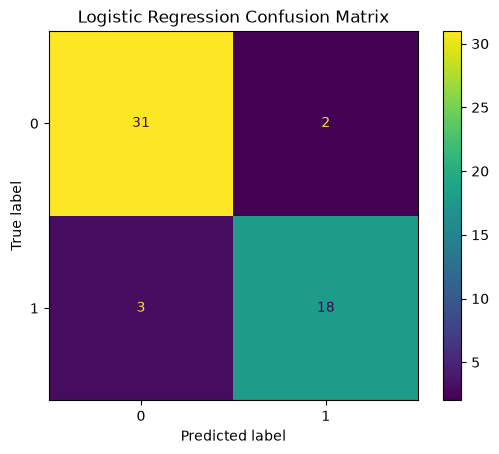

In [79]:
ConfusionMatrixDisplay.from_predictions(y_test, logistic_predict)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Logistic Regression Confusion Matrix Analysis
- True Negatives (0 correctly classified as 0): 31 instances (This implies that the model was able to successfully identify healthy patients).
- True Positives (1 correctly classified as 1): 18 instances (This implies that the model was successful in identifying heart disease patients).
- False Positives (0 incorrectly classified as 1): 2 instances (Type I Error - Healthy patients wrongly classified as sick).
- False Negatives (1 incorrectly classified as 0): 3 instances (Type II Error - Heart disease patients not identified by the model).
General Conclusion: From the confusion matrix analysis, it can be noted that the total number of errors is very small (5 out of 54 instances).

## Model 2: Random Forest
Random Forest is made up of many decision trees and uses the ensemble approach to enhance the performance of predictions.

In [72]:
random_forest=RandomForestClassifier(random_state=42)
random_forest.fit(x_train,y_train)
random_forest_predict=random_forest.predict(x_test)

## Random Forest Evaluation

In [73]:
random_forest_accuracy=accuracy_score(y_test,random_forest_predict)
random_forest_percision=precision_score(y_test,random_forest_predict)
random_forest_recall=recall_score(y_test,random_forest_predict)
random_forest_f1=f1_score(y_test,random_forest_predict)
print("Accuracy:",random_forest_accuracy)
print("Percision:",random_forest_percision)
print("recall:",random_forest_recall)
print("f1:",random_forest_f1)

Accuracy: 0.7962962962962963
Percision: 0.7777777777777778
recall: 0.6666666666666666
f1: 0.717948717948718


In [74]:
print(classification_report(y_test,random_forest_predict))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.78      0.67      0.72        21

    accuracy                           0.80        54
   macro avg       0.79      0.77      0.78        54
weighted avg       0.79      0.80      0.79        54



## Random Forest Classification Results
- Accuracy: 79.6% (Good accuracy and better than the baseline model, but not as good as Logistic Regression).
- Precision: 0.778 (Able to predict with decent accuracy and reduce the number of false positives).
- Recall: 0.667 (Some moderate skills in identifying the positive cases).
- F1-Score: 0.719 (Shows a fair balance between precision and recall with some scope for improvement).

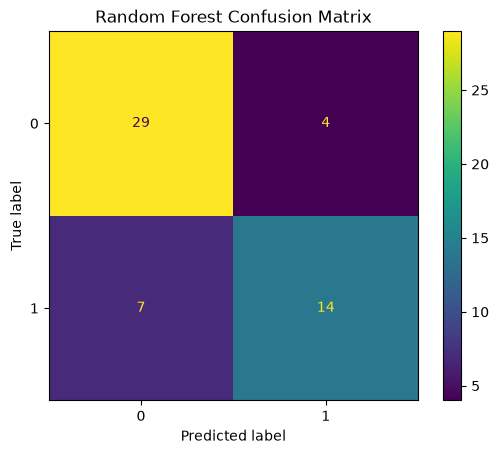

In [78]:
ConfusionMatrixDisplay.from_predictions(y_test, random_forest_predict)
plt.title("Random Forest Confusion Matrix")
plt.show()

## Confusion Matrix for Random Forest
- True Negative (0 predicted as 0): 29 instances (Healthy patients correctly classified).
- True Positive (1 predicted as 1): 14 instances (Heart disease patients correctly detected).
- False Positive (0 predicted as 1): 4 instances (Type 1 Error: Healthy instances wrongly classified as diseased).
- False Negative (1 predicted as 0): 7 instances (Type 2 Error: Heart disease patients wrongly classified as healthy).
Overall Conclusion: The confusion matrix shows that there are 11 total misclassifications out of 54 test instances. Although the model works quite well, it seems to have higher instances of errors (False Negatives) than the Logistic Regression model, meaning that this particular Random Forest model might require optimization to enhance its performance.

In [82]:
results = pd.DataFrame({
    "Model":["Baseline","Logistic Regression","Random Forest"],
    "Accuracy":[
        baseline_accuracy,
        logistic_accuracy,
        random_forest_accuracy
    ],
    "Precision":[
        np.nan,
        logistic_percision,
        random_forest_percision
    ],
    "Recall":[
        np.nan,
        logistic_recall,
        random_forest_recall
    ],
    "F1 Score":[
        np.nan,
        logistic_f1,
        random_forest_f1
    ]
})



In [83]:
results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.907407,0.900000,0.857143,0.878049
2,Random Forest,0.796296,0.777778,0.666667,0.717949
0,Baseline,0.611111,NaN,NaN,NaN


This comparison table summarize the performance of all models using the selected evaluation metrics.

## Final Conclusion
The project has implemented a supervised learning workflow including the following steps:
- Data loading and exploration
- Data pre-processing
- Training and testing datasets splitting 
- Standardization of training data without data leakage 
- Model building 
- Model comparison to a baseline 
The best-performing model received the highest evaluation scores and thus becomes the final model for heart disease prediction.

## Best Model
Logistic Regression proved the best model for this dataset in terms of overall performance.
- It gave the highest values of evaluation metrics while maintaining simplicity, speed, and easiness of usage. Best Accuracy: Got the highest value of accuracy (90.7%), outranking Random Forest (79.6%) and Baseline (61.1%).
- Best Metrics: Demonstrated better results of evaluation metrics, including Precision (0.90), Recall (0.857), and F1-Score (0.878).
- Less Errors: Had less classification errors than Random Forest (only 5 misclassifications).

## Hands-On Lab: End-to-End Mini-Project
All Tasks are Done.